# K-Means Clustering

K-Means is an unsupervised machine learning algorithm, meaning it does not require a target variable to learn from. Instead of predicting a label, it finds clusters in the data based on similarity. 

Here, K-Means is used to group Nepal's local levels into distinct educational profiles based on features like school attendance, literacy outcomes, and educational attainment. This helps the Nepal Ministry of Education identify which types of communities exist across the country and target interventions accordingly, without needing a predefined category system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 1. Load Data and remove target variable

### load Data



In [2]:
df=pd.read_csv('../data/processed_data.csv')
print(df.shape)
df.head()

(17824, 21)


,sex,agegrp,rowtotal_17,rowtotal_18,rowtotal_20,high_illiteracy_risk,early_edu_rate,primary_rate,secondary_rate,slc_rate,...,attending_rate,ever_attending_rate,never_attending_rate,prov_1,prov_2,prov_3,prov_4,prov_5,prov_6,prov_7
0,1,5,144,134,144,1,1.000000,0.000000,0.0,0.0,...,0.930556,0.000000,0.069444,True,False,False,False,False,False,False
1,1,6,132,129,132,1,0.147287,0.852713,0.0,0.0,...,0.977273,0.000000,0.022727,True,False,False,False,False,False,False
2,1,7,122,119,122,1,0.042017,0.957983,0.0,0.0,...,0.975410,0.000000,0.024590,True,False,False,False,False,False,False
3,1,8,113,107,113,1,0.028037,0.971963,0.0,0.0,...,0.946903,0.000000,0.053097,True,False,False,False,False,False,False
4,1,9,127,125,127,0,0.000000,1.000000,0.0,0.0,...,0.960630,0.023622,0.015748,True,False,False,False,False,False,False


## Remove target variable
Since K-Means is unsupervised, it does not use a target variable at all. Including high_illiteracy_risk as a feature would hand the model the answer directly, causing it to cluster based on the label rather than discovering genuine patterns from the education and attendance features. The target column is dropped before any further processing.

In [3]:
# k-means is a unsupervised model, sp remove the target variable illiteracy_risk
X=df.drop(columns=['high_illiteracy_risk'])
X.shape

(17824, 20)

## 2. Feature Scaling

K-Means works by calculating the Euclidean distance between data points to decide which cluster each point belongs to. This means features with larger numeric values will naturally dominate the distance calculation, not because they are more important, but simply because their numbers are bigger.

In this dataset, rowtotal_17, rowtotal_18, and rowtotal_20 contain values in the hundreds to thousands, while all the rate columns (primary_rate, attending_rate, etc.) sit between 0 and 1. Without scaling, the rowtotal columns would overwhelm the distance calculation and the model would cluster almost entirely based on population size, ignoring the carefully engineered education and attendance features entirely.

StandardScaler is used to fix this. It transforms each feature so it has a mean of 0 and a standard deviation of 1, putting all features on the same scale of spread regardless of their original units. Unlike MinMaxScaler (which compresses values into a 0-1 range), StandardScaler handles outliers better and does not assume a hard minimum or maximum boundary for each feature.

In [4]:
# scaling the data
# rowtotal-17 etc have data in hundreds and thousand which will heavilty skew the model solution-> squeeze it between 0 and 1
scaler= StandardScaler() # initialize Standardscaler
X_scaled=scaler.fit_transform(X)
X_scaled.shape

(17824, 20)

## 3. Choosing the Optimal Number of Clusters (Elbow Method)

K-Means requires you to specify the number of clusters (k) upfront, unlike some other algorithms that determine this automatically. Choosing k arbitrarily produces unreliable results, so two methods are used to justify the choice: the Elbow Method and the Silhouette Score.

### Elbow Method

K-Means is run repeatedly for k values from 1 to 10. For each run, the inertia is recorded. Inertia measures how tightly packed the data points are within each cluster (specifically, the sum of squared distances from each point to its assigned cluster center). Lower inertia means tighter, more compact clusters.

As k increases, inertia always decreases (more clusters naturally produce tighter groups). But at some point, adding more clusters stops giving meaningful improvement and the curve flattens out. This flattening point, shaped like an elbow when plotted, is the optimal k where adding more clusters gives diminishing returns.

In [5]:
# using elbow method to find optimal k value
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print(inertia_values)

[356479.999999999, 315387.2517127977, 285889.30110103893, 261873.21066095884, 246347.2803793805, 230966.682677717, 217371.8091109475, 194941.14465670695, 180990.16089515667, 168286.71224653968]


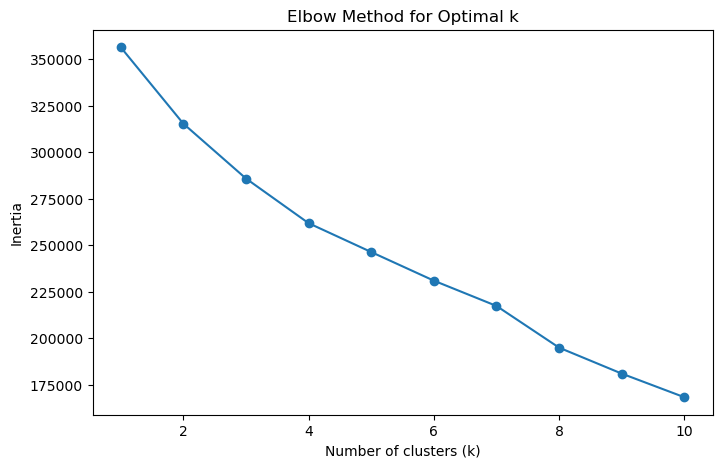

In [6]:


plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

### Silhouette Score

The Elbow Method alone is subjective (different people may see the elbow at different points). The Silhouette Score provides a more objective measure. It evaluates how well-separated the clusters are on a scale from -1 to 1:

- Score close to 1: points are well inside their own cluster and far from others (good separation)
- Score close to 0: points are near the boundary between clusters (ambiguous)
- Score below 0: points may have been assigned to the wrong cluster

The silhouette score was computed for k=2 through k=10. Running this loop on 17,824 rows is computationally expensive (each score compares every point against every other point), which is why the code is commented out after the initial run. The results showed k=6 had a local peak at 0.2007 before the score pattern changed, and the elbow method also suggested k=5 to k=6 as the range of diminishing returns. k=6 was chosen as it balances statistical evidence with practical interpretability (6 distinct educational profiles is far more actionable for a policy audience than k=10 would be).

In [7]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette score needs at least 2 clusters

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.1426
k=3, silhouette score=0.1511
k=4, silhouette score=0.1652
k=5, silhouette score=0.1771
k=6, silhouette score=0.2007
k=7, silhouette score=0.1895
k=8, silhouette score=0.3134
k=9, silhouette score=0.3170
k=10, silhouette score=0.3182


## 4. Final Model (k=6)

The final K-Means model is run with k=6 based on the combined evidence from the Elbow Method and Silhouette Score analysis above.

Two key parameters are set:
- random_state=42: makes the results reproducible. K-Means has randomness in how it initializes cluster centers, so without fixing a random seed, you would get slightly different results each run.
- n_init=10: runs the algorithm 10 times with different random starting points and keeps the best result. This reduces the risk of the model getting stuck in a suboptimal solution due to a poor random initialization.

The resulting cluster labels (0 through 5) are added back to the original dataframe as a new column, so the clusters can be analyzed and interpreted alongside the original features.

In [8]:
model_kmeans=KMeans(n_clusters=6,random_state=42,n_init=10) # k =6, n_int=10 means model runs 10 time on 10 random starting point
cluster_labels = model_kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels
print(df['cluster'].value_counts())

cluster
1    6227
4    3744
0    3095
5    2358
2    1997
3     403
Name: count, dtype: int64


## 5. Cluster Interpretation

Cluster numbers alone (0, 1, 2...) are meaningless labels. To understand what each cluster actually represents in real-world terms, the average value of key features is calculated within each cluster. This "profile" reveals the characteristics that define each group, allowing the clusters to be interpreted as distinct educational communities across Nepal's local levels.

In [9]:
cluster_profile = df.groupby('cluster')[['primary_rate', 'secondary_rate', 'no_education_rate',
                                            'attending_rate', 'never_attending_rate', 'high_illiteracy_risk']].mean()
print(cluster_profile)

         primary_rate  secondary_rate  no_education_rate  attending_rate  \
cluster                                                                    
0            0.566099        0.236771           0.002437        0.799530   
1            0.734021        0.041651           0.001253        0.948216   
2            0.562592        0.278812           0.000418        0.932988   
3            0.518051        0.306872           0.000693        0.935361   
4            0.189378        0.778980           0.001974        0.935817   
5            0.573866        0.250706           0.000879        0.929830   

         never_attending_rate  high_illiteracy_risk  
cluster                                              
0                    0.147430              0.971244  
1                    0.027015              0.479043  
2                    0.031918              0.460190  
3                    0.029661              0.416873  
4                    0.013067              0.214476  
5            

In [10]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(X_scaled, cluster_labels)
print("Final silhouette score (k=6):", final_silhouette)

Final silhouette score (k=6): 0.20072577702677588


## 6. Visualization using PCA

K-Means clustered the data across 20 features simultaneously, which cannot be directly visualized. Principal Component Analysis (PCA) is used to reduce these 20 dimensions down to just 2, so the clusters can be plotted on a standard 2D scatter chart.

PCA works by finding the directions of maximum variance in the data and projecting all points onto these directions. The first two principal components (the two directions that capture the most variance) are used as the x and y axes of the plot.

Important limitation: the two principal components only capture 30.6% of the total variance in the original 20-dimensional data. This means the 2D plot is an incomplete representation of the actual clustering, and some overlap visible in the plot does not necessarily mean the clusters are poorly separated in the original high-dimensional space. The silhouette score (calculated in the original 20D space, not the reduced 2D space) is a more reliable measure of actual cluster quality than the visual appearance of this plot alone.

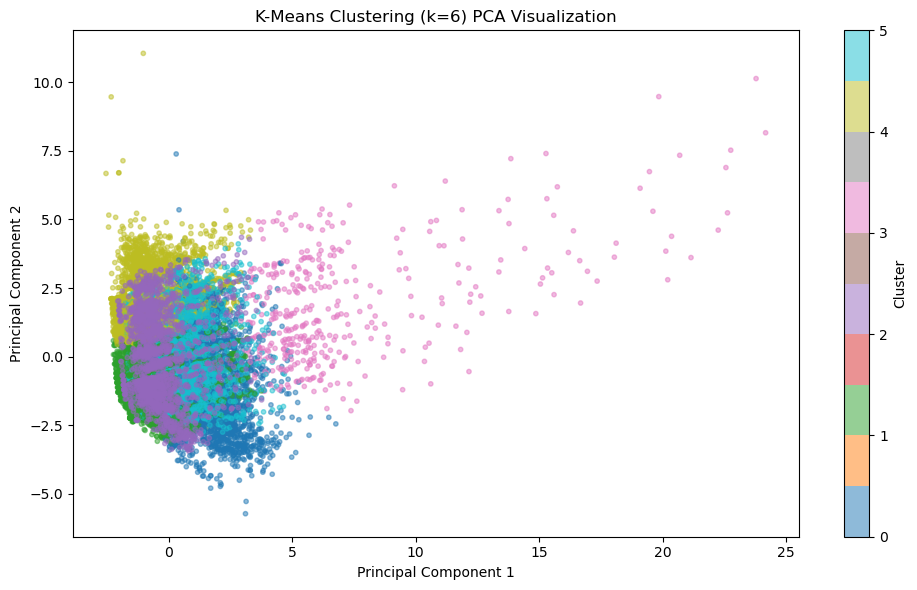

Explained variance ratio: [0.15793982 0.14816113]
Total variance explained: 0.30610095208609367


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clustering (k=6) PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('../results/kmeans_clusters.png', dpi=150)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

## 7. Evaluation and Interpretation

The final silhouette score of 0.2007 indicates moderate cluster cohesion. On a scale of -1 to 1, scores above 0.5 are considered strong, while 0.2 to 0.5 indicates clusters exist but are not sharply separated. This is expected for census aggregate data, where educational outcomes tend to vary gradually across communities rather than falling into perfectly distinct groups.

Looking at the cluster profiles:

Cluster 0 is the most critical finding: it has by far the highest never_attending_rate (14.7%) and the highest illiteracy risk (97%). This represents communities where children are significantly less likely to ever attend school, and should be the highest priority for Ministry of Education intervention.

Cluster 4 stands out as the most distinct group both statistically and visually in the PCA plot. It has the highest secondary_rate (78%) and lowest illiteracy risk (21%), representing older cohorts (ages 13-15) who have successfully progressed through primary into secondary education.

Clusters 1, 2, 3, and 5 represent broadly "average" educational profiles with moderate primary attendance and illiteracy risk around 42-48%, reflecting the typical local level across Nepal.

The overall finding suggests Nepal's educational landscape is not sharply divided but exists on a continuum, with one clearly vulnerable extreme (Cluster 0) and one clearly successful extreme (Cluster 4), and a large middle ground in between.